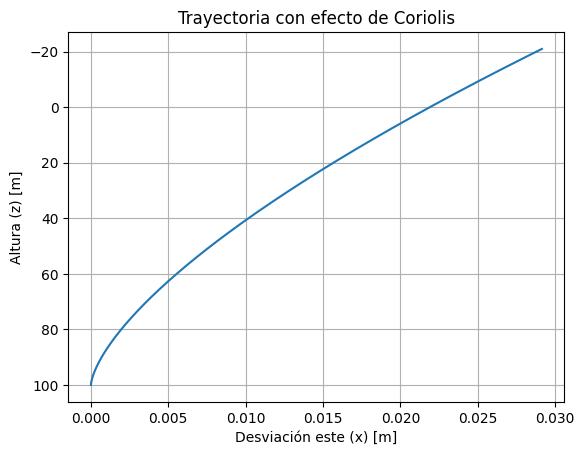

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros físicos
g = 9.81              # gravedad
Omega = 7.292e-5      # rotación terrestre [rad/s]
lambda_deg = 86       # latitud [grados]
h = 100               # altura inicial [m]

# Convertir latitud a radianes
lambda_rad = np.radians(lambda_deg)

# Ecuaciones de movimiento
def coriolis(t, y):
    x, y_, z, vx, vy, vz = y
    ax = 2 * Omega * (vy * np.cos(lambda_rad) - vz * np.sin(lambda_rad))
    ay = -2 * Omega * vx * np.cos(lambda_rad)
    az = -g + 2 * Omega * vx * np.sin(lambda_rad)
    return [vx, vy, vz, ax, ay, az]

# Condiciones iniciales
y0 = [0, 0, h, 0, 0, 0]

# Tiempo máximo (caída libre sin Coriolis)
t_final = np.sqrt(2*h/g) * 1.1
t_span = (0, t_final)
t_eval = np.linspace(0, t_final, 1000)

# Resolver ODE
sol = solve_ivp(coriolis, t_span, y0, t_eval=t_eval)

# Extraer soluciones
x, y_, z = sol.y[0], sol.y[1], sol.y[2]

# Mostrar resultado
plt.plot(x, z)
plt.xlabel('Desviación este (x) [m]')
plt.ylabel('Altura (z) [m]')
plt.title('Trayectoria con efecto de Coriolis')
plt.grid()
plt.gca().invert_yaxis()
plt.show()